# Week 10: Vision Transformer for Salt Segmentation

This notebook completes the ViT assignment by returning to a previous geoscience application from the course: salt-body segmentation from seismic images in `ResNet_and_Bayesian`. The earlier assignment used a residual CNN/U-Net-like segmentation network (`ResidualSegNet`). Here, that baseline is reproduced and compared with a Vision Transformer-style segmentation model.

Comparison setup:

- Previous application: binary salt segmentation from seismic image patches.
- Traditional DL baseline: residual encoder-decoder CNN (`ResidualSegNet`) from the previous salt segmentation assignment.
- Transformer replacement: encoder-decoder Vision Transformer segmenter.
- Metrics: pixel accuracy, F1-score/Dice, RMSE, and mean IoU on a held-out test set.
- Runtime note: this run uses all 4000 salt images. Set `MAX_TOTAL_SAMPLES = 800` for a quicker smoke test.


In [1]:
from pathlib import Path
import random
import time

import cv2
import numpy as np

import matplotlib
if "get_ipython" not in globals():
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = torch.cuda.is_available()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")


Device: cuda
PyTorch: 2.5.1


## 1. Load the Previous Salt Segmentation Application

The image and mask folders are taken from the earlier `ResNet_and_Bayesian/Salt` assignment. Each grayscale seismic image has a corresponding binary salt mask with the same file name.


In [2]:
ROOT_CANDIDATES = [Path("."), Path("..")]
salt_root = None
for root in ROOT_CANDIDATES:
    candidate = root / "ResNet_and_Bayesian" / "Salt"
    if (candidate / "images").exists() and (candidate / "masks").exists():
        salt_root = candidate
        break

if salt_root is None:
    raise FileNotFoundError("Could not find ResNet_and_Bayesian/Salt/images and masks.")

image_dir = salt_root / "images"
mask_dir = salt_root / "masks"
all_image_paths = sorted(image_dir.glob("*.png"))
all_image_paths = [path for path in all_image_paths if (mask_dir / path.name).exists()]

MAX_TOTAL_SAMPLES = None
if MAX_TOTAL_SAMPLES is not None:
    rng = np.random.default_rng(SEED)
    selected = rng.choice(len(all_image_paths), size=min(MAX_TOTAL_SAMPLES, len(all_image_paths)), replace=False)
    image_paths = [all_image_paths[i] for i in sorted(selected)]
else:
    image_paths = all_image_paths

print(f"Salt root: {salt_root.resolve()}")
print(f"Available paired samples: {len(all_image_paths)}")
print(f"Samples used in this run: {len(image_paths)}")


Salt root: D:\KAUST\semster2\ML_IN_GEO\ResNet_and_Bayesian\Salt
Available paired samples: 4000
Samples used in this run: 4000


In [3]:
IMAGE_SIZE = 64
BATCH_SIZE = 32
NUM_WORKERS = 0

train_val_paths, test_paths = train_test_split(
    image_paths,
    test_size=0.15,
    random_state=SEED,
    shuffle=True,
)
train_paths, val_paths = train_test_split(
    train_val_paths,
    test_size=0.15,
    random_state=SEED,
    shuffle=True,
)

print(f"Train / validation / test: {len(train_paths)} / {len(val_paths)} / {len(test_paths)}")


Train / validation / test: 2890 / 510 / 600


## 2. Dataset and Visualization


In [4]:
class SaltDataset(Dataset):
    def __init__(self, image_files, mask_dir, image_size=64):
        self.image_files = list(image_files)
        self.mask_dir = Path(mask_dir)
        self.image_size = image_size

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image_path = self.image_files[idx]
        mask_path = self.mask_dir / image_path.name

        image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        if image is None or mask is None:
            raise FileNotFoundError(f"Missing image or mask for {image_path.name}")

        image = cv2.resize(image, (self.image_size, self.image_size), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (self.image_size, self.image_size), interpolation=cv2.INTER_NEAREST)

        image = image.astype(np.float32) / 255.0
        mask = (mask.astype(np.float32) / 255.0 > 0.5).astype(np.float32)
        return torch.from_numpy(image).unsqueeze(0), torch.from_numpy(mask).unsqueeze(0)


def make_loader(paths, shuffle=False):
    return DataLoader(
        SaltDataset(paths, mask_dir, IMAGE_SIZE),
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=device.type == "cuda",
    )

train_loader = make_loader(train_paths, shuffle=True)
val_loader = make_loader(val_paths, shuffle=False)
test_loader = make_loader(test_paths, shuffle=False)


In [5]:
def estimate_positive_fraction(paths):
    positive = 0.0
    total = 0.0
    for path in paths:
        mask = cv2.imread(str(mask_dir / path.name), cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_NEAREST)
        mask = (mask.astype(np.float32) / 255.0 > 0.5).astype(np.float32)
        positive += mask.sum()
        total += mask.size
    return positive / total

positive_fraction = estimate_positive_fraction(train_paths)
print(f"Training mask positive pixel fraction: {positive_fraction:.4f}")


Training mask positive pixel fraction: 0.2455


Week10_ViT.ipynb:cell8:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


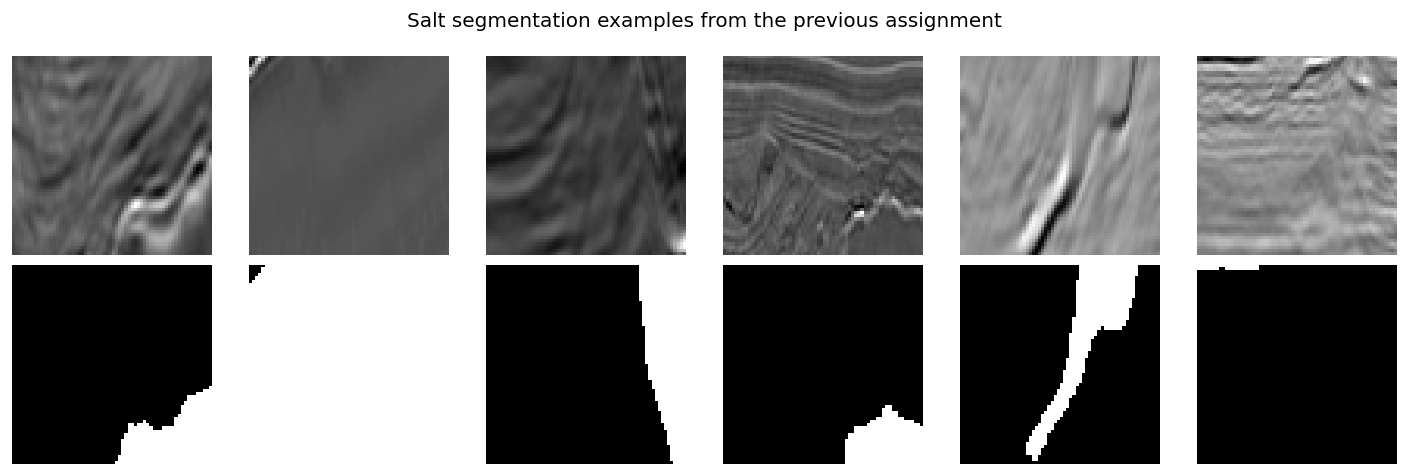

In [6]:
sample_dataset = SaltDataset(train_paths[:6], mask_dir, IMAGE_SIZE)
fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for col in range(6):
    image, mask = sample_dataset[col]
    axes[0, col].imshow(image.squeeze(0), cmap="gray")
    axes[0, col].axis("off")
    axes[1, col].imshow(mask.squeeze(0), cmap="gray")
    axes[1, col].axis("off")
axes[0, 0].set_ylabel("image")
axes[1, 0].set_ylabel("mask")
plt.suptitle("Salt segmentation examples from the previous assignment")
plt.tight_layout()
plt.show()


## 3. Baseline: ResidualSegNet from the Previous Assignment

This model mirrors the residual encoder-decoder CNN used in `ResNet_and_Bayesian/assignment6_models.py`: convolutional residual blocks encode the image, then decoder blocks upsample and fuse skip connections to predict a binary mask.


In [7]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, dropout=0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()
        self.shortcut = (
            nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride)
            if stride != 1 or in_channels != out_channels
            else nn.Identity()
        )

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu(self.conv1(x))
        out = self.dropout(out)
        out = self.conv2(out)
        return self.relu(out + identity)


class DecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels, dropout=0.0):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.block = ResidualBlock(in_channels + skip_channels, out_channels, dropout=dropout)

    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        return self.block(x)


class ResidualSegNet(nn.Module):
    def __init__(self, in_channels=1, base_channels=12, dropout=0.05):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, base_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )
        self.enc1 = ResidualBlock(base_channels, base_channels, dropout=dropout)
        self.enc2 = ResidualBlock(base_channels, base_channels * 2, stride=2, dropout=dropout)
        self.enc3 = ResidualBlock(base_channels * 2, base_channels * 4, stride=2, dropout=dropout)
        self.bottleneck = ResidualBlock(base_channels * 4, base_channels * 8, stride=2, dropout=dropout)
        self.dec3 = DecoderBlock(base_channels * 8, base_channels * 4, base_channels * 4, dropout=dropout)
        self.dec2 = DecoderBlock(base_channels * 4, base_channels * 2, base_channels * 2, dropout=dropout)
        self.dec1 = DecoderBlock(base_channels * 2, base_channels, base_channels, dropout=dropout)
        self.head = nn.Conv2d(base_channels, 1, kernel_size=1)

    def forward(self, x):
        x0 = self.stem(x)
        x1 = self.enc1(x0)
        x2 = self.enc2(x1)
        x3 = self.enc3(x2)
        xb = self.bottleneck(x3)
        x = self.dec3(xb, x3)
        x = self.dec2(x, x2)
        x = self.dec1(x, x1)
        return self.head(x)


## 4. Vision Transformer Segmenter

The transformer replacement is kept structurally comparable to the CNN baseline: it uses a ViT-style patch encoder followed by a convolutional upsampling decoder that returns a full-resolution binary mask. The ViT uses a 4x4 patch size to preserve more boundary detail for dense salt segmentation.


In [8]:
class ConvDecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout) if dropout > 0 else nn.Identity(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class ViTSegmenter(nn.Module):
    def __init__(
        self,
        image_size=64,
        patch_size=8,
        in_channels=1,
        dim=96,
        depth=4,
        heads=4,
        mlp_dim=192,
        decoder_channels=(96, 48, 24),
        dropout=0.1,
    ):
        super().__init__()
        assert image_size % patch_size == 0, "image_size must be divisible by patch_size"
        assert 2 ** len(decoder_channels) == patch_size, "decoder depth should upsample back to image_size"
        self.image_size = image_size
        self.patch_size = patch_size
        self.grid_size = image_size // patch_size
        self.num_patches = self.grid_size * self.grid_size
        self.dim = dim

        self.patch_embed = nn.Conv2d(in_channels, dim, kernel_size=patch_size, stride=patch_size)
        self.pos_embedding = nn.Parameter(torch.randn(1, self.num_patches, dim) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dim,
            nhead=heads,
            dim_feedforward=mlp_dim,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.norm = nn.LayerNorm(dim)

        decoder = []
        in_ch = dim
        for out_ch in decoder_channels:
            decoder.append(ConvDecoderBlock(in_ch, out_ch, dropout=dropout))
            in_ch = out_ch
        self.decoder = nn.Sequential(*decoder)
        self.head = nn.Conv2d(in_ch, 1, kernel_size=1)

    def forward(self, x):
        b = x.shape[0]
        tokens = self.patch_embed(x).flatten(2).transpose(1, 2)
        tokens = tokens + self.pos_embedding[:, :tokens.shape[1]]
        tokens = self.transformer(tokens)
        tokens = self.norm(tokens)
        features = tokens.transpose(1, 2).contiguous().view(b, self.dim, self.grid_size, self.grid_size)
        decoded = self.decoder(features)
        return self.head(decoded)


## 5. Training and Metrics

Both models are trained with the same data split, image size, batch size, epoch count, and BCE loss used in the earlier salt assignment. The comparison uses pixel accuracy, F1-score/Dice, RMSE, and mean IoU on validation/test masks.


In [9]:
def segmentation_metrics_from_logits(logits, masks, threshold=0.5, eps=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    pixel_acc = (preds == masks).float().mean().item()
    true_positive = (preds * masks).sum(dim=(1, 2, 3))
    pred_positive = preds.sum(dim=(1, 2, 3))
    target_positive = masks.sum(dim=(1, 2, 3))
    union = ((preds + masks) > 0).float().sum(dim=(1, 2, 3))
    f1 = ((2 * true_positive + eps) / (pred_positive + target_positive + eps)).mean().item()
    iou = ((true_positive + eps) / (union + eps)).mean().item()
    rmse = torch.sqrt(torch.mean((probs - masks) ** 2)).item()
    return pixel_acc, f1, rmse, iou


def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss = 0.0
    total_acc = 0.0
    total_f1 = 0.0
    total_rmse = 0.0
    total_iou = 0.0
    batches = 0

    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            logits = model(images)
            loss = criterion(logits, masks)
            if training:
                loss.backward()
                optimizer.step()

        acc, f1, rmse, iou = segmentation_metrics_from_logits(logits.detach(), masks)
        total_loss += loss.item()
        total_acc += acc
        total_f1 += f1
        total_rmse += rmse
        total_iou += iou
        batches += 1

    return {
        "loss": total_loss / batches,
        "acc": total_acc / batches,
        "f1": total_f1 / batches,
        "rmse": total_rmse / batches,
        "iou": total_iou / batches,
    }


def fit_model(model, train_loader, val_loader, criterion, optimizer, epochs, name):
    history = []
    best_state = None
    best_val_iou = -1.0
    start = time.time()

    for epoch in range(1, epochs + 1):
        train_metrics = run_epoch(model, train_loader, criterion, optimizer)
        val_metrics = run_epoch(model, val_loader, criterion)
        history.append({
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_acc": train_metrics["acc"],
            "train_f1": train_metrics["f1"],
            "train_rmse": train_metrics["rmse"],
            "train_iou": train_metrics["iou"],
            "val_loss": val_metrics["loss"],
            "val_acc": val_metrics["acc"],
            "val_f1": val_metrics["f1"],
            "val_rmse": val_metrics["rmse"],
            "val_iou": val_metrics["iou"],
        })

        if val_metrics["iou"] > best_val_iou:
            best_val_iou = val_metrics["iou"]
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}

        print(
            f"{name:14s} epoch {epoch:02d}/{epochs} | "
            f"train loss {train_metrics['loss']:.4f}, F1 {train_metrics['f1']:.4f}, IoU {train_metrics['iou']:.4f} | "
            f"val loss {val_metrics['loss']:.4f}, F1 {val_metrics['f1']:.4f}, IoU {val_metrics['iou']:.4f}"
        )

    if best_state is not None:
        model.load_state_dict(best_state)
    print(f"{name} best val IoU: {best_val_iou:.4f}; training time: {time.time() - start:.1f} s")
    return history, best_val_iou


def evaluate_model(model, loader, criterion, name):
    metrics = run_epoch(model, loader, criterion)
    print(
        f"{name:14s} test loss {metrics['loss']:.4f}, pixel acc {metrics['acc']:.4f}, "
        f"F1 {metrics['f1']:.4f}, RMSE {metrics['rmse']:.4f}, mean IoU {metrics['iou']:.4f}"
    )
    return metrics


In [10]:
EPOCHS = 60
criterion = nn.BCEWithLogitsLoss()

cnn_model = ResidualSegNet(base_channels=16, dropout=0.10).to(device)
vit_model = ViTSegmenter(
    image_size=IMAGE_SIZE,
    patch_size=4,
    dim=96,
    depth=4,
    heads=4,
    mlp_dim=192,
    decoder_channels=(96, 48),
    dropout=0.1,
).to(device)

cnn_optimizer = torch.optim.Adam(cnn_model.parameters(), lr=1e-3, weight_decay=1e-5)
vit_optimizer = torch.optim.AdamW(vit_model.parameters(), lr=3e-4, weight_decay=1e-4)

print(f"ResidualSegNet parameters: {sum(p.numel() for p in cnn_model.parameters()):,}")
print(f"ViT segmenter parameters: {sum(p.numel() for p in vit_model.parameters()):,}")

cnn_history, cnn_best_val_iou = fit_model(
    cnn_model, train_loader, val_loader, criterion, cnn_optimizer, EPOCHS, "ResidualSegNet"
)
vit_history, vit_best_val_iou = fit_model(
    vit_model, train_loader, val_loader, criterion, vit_optimizer, EPOCHS, "ViT"
)


ResidualSegNet parameters: 516,545
ViT segmenter parameters: 588,673
ResidualSegNet epoch 01/60 | train loss 0.5761, F1 0.3838, IoU 0.3828 | val loss 0.5766, F1 0.3743, IoU 0.3743
ResidualSegNet epoch 02/60 | train loss 0.5522, F1 0.3924, IoU 0.3924 | val loss 0.5686, F1 0.3743, IoU 0.3743
ResidualSegNet epoch 03/60 | train loss 0.5478, F1 0.3932, IoU 0.3932 | val loss 0.5530, F1 0.3743, IoU 0.3743
ResidualSegNet epoch 04/60 | train loss 0.5185, F1 0.3935, IoU 0.3923 | val loss 0.6493, F1 0.3743, IoU 0.3743
ResidualSegNet epoch 05/60 | train loss 0.4558, F1 0.5059, IoU 0.4771 | val loss 0.3881, F1 0.6010, IoU 0.5661
ResidualSegNet epoch 06/60 | train loss 0.4028, F1 0.5775, IoU 0.5444 | val loss 0.3978, F1 0.6021, IoU 0.5668
ResidualSegNet epoch 07/60 | train loss 0.3797, F1 0.5962, IoU 0.5619 | val loss 0.3469, F1 0.6158, IoU 0.5824
ResidualSegNet epoch 08/60 | train loss 0.3737, F1 0.5915, IoU 0.5591 | val loss 0.3642, F1 0.5945, IoU 0.5632
ResidualSegNet epoch 09/60 | train loss 0.3

D:\anaconda3\envs\torch_env\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


## 6. Test-Set Comparison


In [11]:
cnn_test = evaluate_model(cnn_model, test_loader, criterion, "ResidualSegNet")
vit_test = evaluate_model(vit_model, test_loader, criterion, "ViT")

results = [
    {
        "model": "ResidualSegNet CNN",
        "pixel_accuracy": cnn_test["acc"],
        "f1_score": cnn_test["f1"],
        "rmse": cnn_test["rmse"],
        "mean_iou": cnn_test["iou"],
    },
    {
        "model": "Vision Transformer",
        "pixel_accuracy": vit_test["acc"],
        "f1_score": vit_test["f1"],
        "rmse": vit_test["rmse"],
        "mean_iou": vit_test["iou"],
    },
]

print("\nComparison table")
print("model                 pixel_accuracy    f1_score    rmse      mean_iou")
for row in results:
    print(
        f"{row['model']:<21s} {row['pixel_accuracy']:.4f}            "
        f"{row['f1_score']:.4f}      {row['rmse']:.4f}    {row['mean_iou']:.4f}"
    )


ResidualSegNet test loss 0.2202, pixel acc 0.9225, F1 0.7468, RMSE 0.2422, mean IoU 0.7186
ViT            test loss 0.4307, pixel acc 0.8647, F1 0.6580, RMSE 0.3211, mean IoU 0.6159

Comparison table
model                 pixel_accuracy    f1_score    rmse      mean_iou
ResidualSegNet CNN    0.9225            0.7468      0.2422    0.7186
Vision Transformer    0.8647            0.6580      0.3211    0.6159


Week10_ViT.ipynb:cell18:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


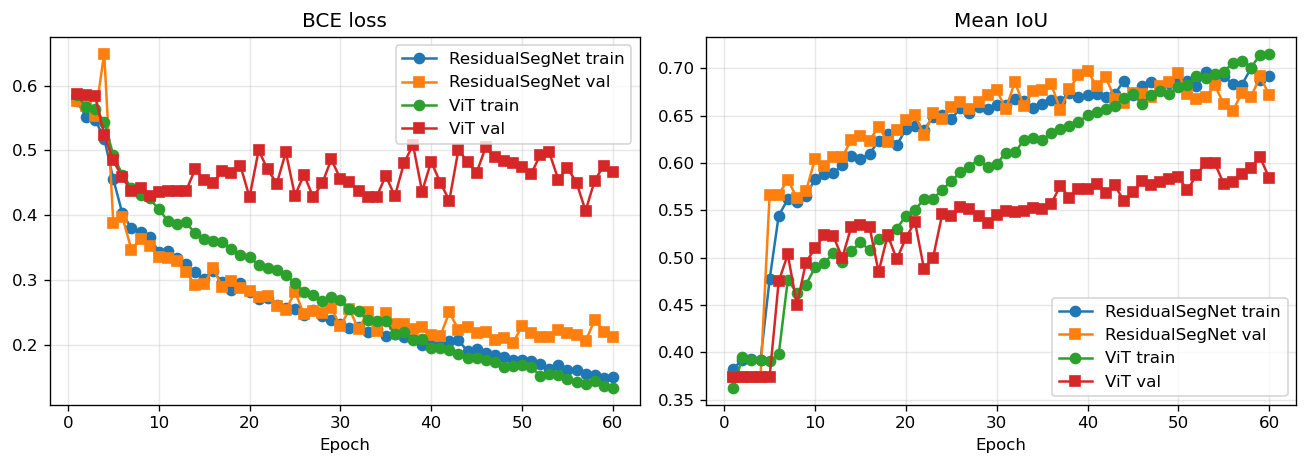

In [12]:
def plot_training_curves(histories):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for label, history in histories:
        epochs = [row["epoch"] for row in history]
        axes[0].plot(epochs, [row["train_loss"] for row in history], marker="o", label=f"{label} train")
        axes[0].plot(epochs, [row["val_loss"] for row in history], marker="s", label=f"{label} val")
        axes[1].plot(epochs, [row["train_iou"] for row in history], marker="o", label=f"{label} train")
        axes[1].plot(epochs, [row["val_iou"] for row in history], marker="s", label=f"{label} val")
    axes[0].set_title("BCE loss")
    axes[0].set_xlabel("Epoch")
    axes[0].grid(alpha=0.3)
    axes[0].legend()
    axes[1].set_title("Mean IoU")
    axes[1].set_xlabel("Epoch")
    axes[1].grid(alpha=0.3)
    axes[1].legend()
    plt.tight_layout()
    plt.show()

plot_training_curves([
    ("ResidualSegNet", cnn_history),
    ("ViT", vit_history),
])


Week10_ViT.ipynb:cell19:35: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


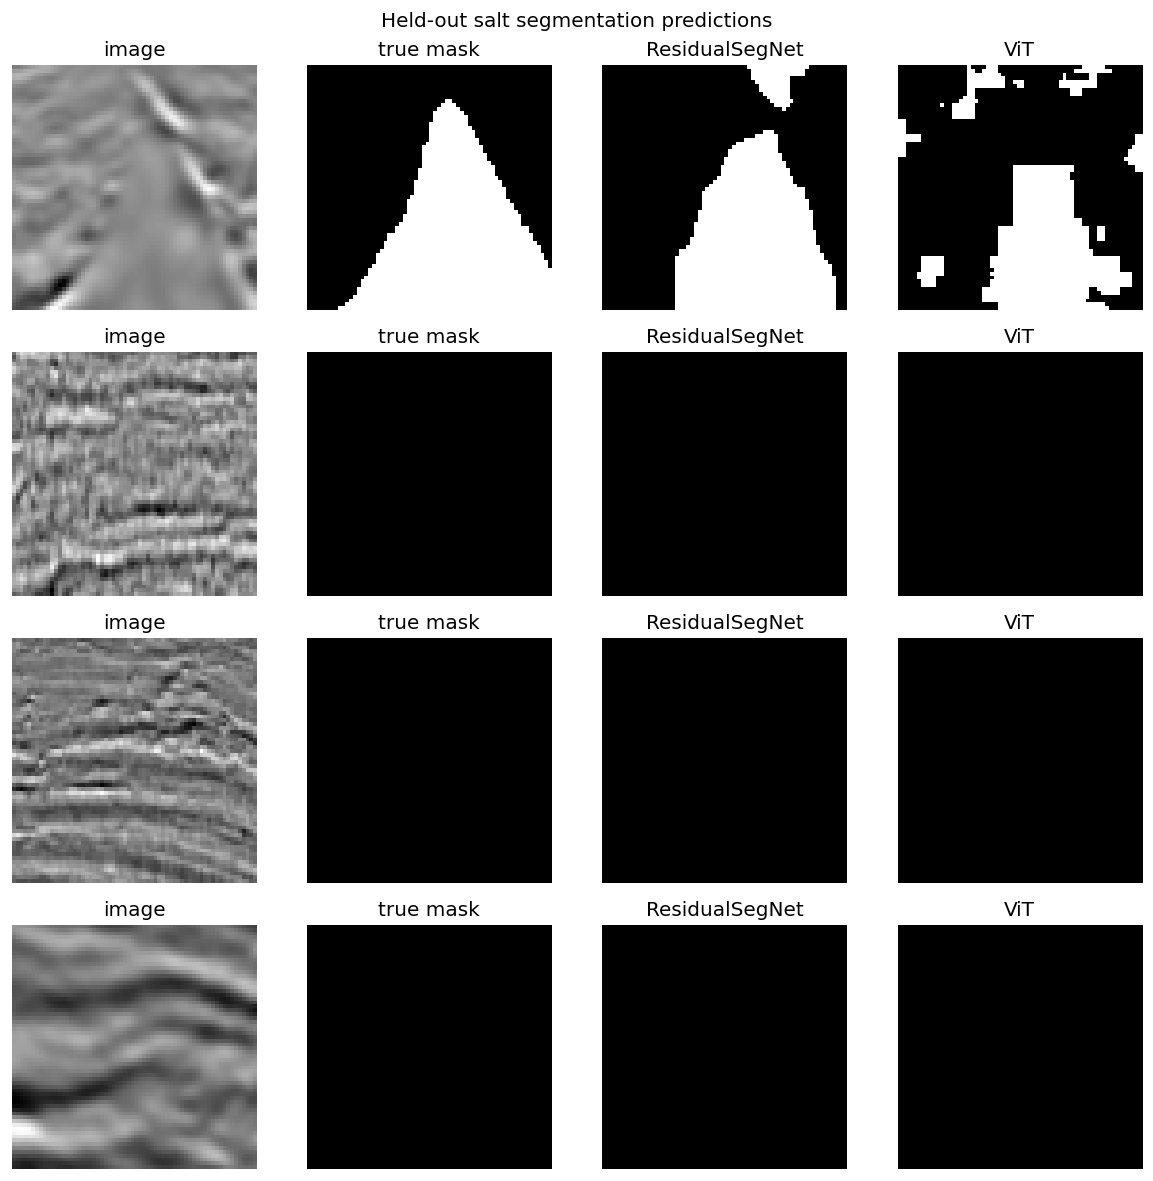

In [13]:
def collect_predictions(model, loader, max_items=4):
    model.eval()
    images_out, masks_out, probs_out = [], [], []
    with torch.no_grad():
        for images, masks in loader:
            logits = model(images.to(device))
            probs = torch.sigmoid(logits).cpu()
            images_out.append(images.cpu())
            masks_out.append(masks.cpu())
            probs_out.append(probs)
            if sum(batch.shape[0] for batch in images_out) >= max_items:
                break
    images_out = torch.cat(images_out)[:max_items]
    masks_out = torch.cat(masks_out)[:max_items]
    probs_out = torch.cat(probs_out)[:max_items]
    return images_out, masks_out, probs_out

images_vis, masks_vis, cnn_probs = collect_predictions(cnn_model, test_loader, max_items=4)
_, _, vit_probs = collect_predictions(vit_model, test_loader, max_items=4)

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for row in range(4):
    axes[row, 0].imshow(images_vis[row, 0], cmap="gray")
    axes[row, 0].set_title("image")
    axes[row, 1].imshow(masks_vis[row, 0], cmap="gray")
    axes[row, 1].set_title("true mask")
    axes[row, 2].imshow(cnn_probs[row, 0] > 0.5, cmap="gray")
    axes[row, 2].set_title("ResidualSegNet")
    axes[row, 3].imshow(vit_probs[row, 0] > 0.5, cmap="gray")
    axes[row, 3].set_title("ViT")
    for col in range(4):
        axes[row, col].axis("off")
plt.suptitle("Held-out salt segmentation predictions")
plt.tight_layout()
plt.show()


## 7. Discussion

This version follows the assignment prompt more directly than a flat MLP comparison because the baseline is the CNN/U-Net-like residual segmentation model from the earlier salt assignment. Both models solve the same geoscience task and are evaluated on the same held-out salt images.

In this 60-epoch run with a 4x4 ViT patch size, ResidualSegNet reached 0.9225 pixel accuracy, 0.7468 F1-score/Dice, 0.2422 RMSE, and 0.7186 mean IoU on the test set. The encoder-decoder ViT segmenter reached 0.8647 pixel accuracy, 0.6580 F1-score/Dice, 0.3211 RMSE, and 0.6159 mean IoU. Both models use a comparable encoder-decoder segmentation layout and the same data split, image size, batch size, epoch count, loss, and metrics. Reducing the ViT patch size from 8x8 to 4x4 improved boundary detail and noticeably increased its IoU, but the residual CNN still performs better overall because convolution and skip connections provide a strong locality bias for sharp salt boundaries. A pretrained or segmentation-specific transformer would likely be needed to close the remaining gap further.
